# Fase 4 — Memòria d'Oponent (LSTM) i adaptació dins la sessió

**Continuació de:** [`35_init_cos/comparacio_fase35.ipynb`](../3_feature_extractor/35_init_cos/comparacio_fase35.ipynb)

Aquest notebook analitza la Fase 4 del TFG. Els fonaments teòrics es troben a [`14_Fase4_MarcTeoric`](../../14_Fase4_MarcTeoric.md) i els detalls d'implementació a [`15_Fase4_Implementacio`](../../15_Fase4_Implementacio.md).

> **Q3:** Pot un agent amb memòria (LSTM) adaptar-se al comportament d'un oponent desconegut al llarg d'una sessió de mans consecutives?

## Disseny experimental

| Run | Memòria | Pool divers | Sessions | Font |
|:--|:--|:--|:--|:--|
| DQN frozen (F3.5) | No | No | No | reutilitzat |
| PPO frozen (F3.5) | No | No | No | reutilitzat |
| F4-ablació | No | Sí (6 variants) | N=5 mans | nou |
| F4-complet | LSTM 256 | Sí (6 variants) | N=5 mans | nou |

**Nota sobre protocols:** L'entrenament usa sessions de N=5 **mans** (`TrucGymEnvMa`). L'avaluació usa sessions de N=5 **partides senceres** (`TrucEnv`) per comparabilitat amb F3.5. Aquesta discrepància de context (50 steps d'entrenament vs ~500 d'avaluació) és un factor limitant per a H2.

**Hipòtesis:**
- **H1**: F4-complet > F4-ablació en WR global (≥ +3 pp).
- **H2**: F4-complet mostra WR_pos_5 − WR_pos_1 ≥ +5 pp (per posició de partida sencera dins la sessió d'avaluació).
- **H3**: F4-ablació ≈ F3.5 PPO frozen (±3 pp).


---
## 1. Context teòric

### 1.1 El model de memòria: LSTM

Una xarxa LSTM (Long Short-Term Memory) manté dos vectors d'estat `(h_t, c_t)` que evolucionen al llarg del temps:
- `c_t` (cell state): memòria a llarg termini, modificada gradualment pels gates.
- `h_t` (hidden state): sortida visible a la capa següent, actua com a context condensat.

A cada step `t`, l'LSTM rep l'entrada `x_t` (en el nostre cas, les 256 dims del COS preentrenat) i produeix `(h_t, c_t)` a partir de `(h_{t-1}, c_{t-1}, x_t)`. El gradient a través del temps (BPTT) permet que l'agent aprengui a desar informació rellevant al principi de la sessió i recuperar-la més tard.

`RecurrentPPO` (de `sb3_contrib`) implementa PPO amb LSTM via **truncated BPTT**. El flag `episode_start` marca quan resetejar l'estat LSTM: `terminated=True` al step anterior implica reset a zeros al step següent.

### 1.2 Arquitectura F4-complet

```
obs (240) : CosMultiInputSB3 (frozen, 256) : LSTM(256) : MLP [256] : policy/value heads
```

El COS preentrenat i congelat produeix embeddings estables. L'LSTM hi acumula el context temporal per detectar patrons de l'oponent. El MLP final és lleuger perquè l'LSTM ja fa la feina representacional.

### 1.3 Sessions multi-mà (episodi RL = N=5 mans)

`TrucGymEnvSessio` envolta `TrucGymEnvMa`, on **cada episodi de l'entorn intern correspon a una mà completa** (no una partida sencera). Per tant, una sessió de N=5 encadena **5 mans consecutives** contra el mateix oponent:

- L'entorn intern (`TrucGymEnvMa`) retorna `terminated=True` al final de cada **mà**.
- El wrapper intercepta aquest senyal i el propaga **només** al final de les 5 mans.
- Dins la sessió, l'estat LSTM es manté viu i pot acumular informació cross-mans.

Al principi de cada sessió es sampeja un oponent nou del pool. El reset de l'LSTM coincideix amb el canvi d'oponent. Nota: les `wr_pos_1..wr_pos_5` del log mesuren el WR agregat per posició de **mà** dins la sessió, no per partida.

### 1.4 El pool de 6 variants

| Nom | truc_agressio | envit_agressio | farol_prob | resposta_truc |
|:--|--:|--:|--:|--:|
| Conservador | 0.5 | 0.5 | 0.02 | 0.6 |
| Agressiu | 1.8 | 1.8 | 0.30 | 1.5 |
| Truc-bot | 2.0 | 0.4 | 0.15 | 1.2 |
| Envit-bot | 0.4 | 2.0 | 0.05 | 0.7 |
| Faroler | 1.3 | 1.3 | 0.40 | 1.3 |
| Equilibrat | 1.0 | 1.0 | 0.12 | 1.0 |

Un oponent fix no obliga l'agent a aprendre a adaptar-se. Amb sis variants diferenciades no existeix una política única òptima: cal detectar qui tens al davant.

### 1.5 Per què RecurrentPPO i no DRQN

DRQN requeriria un replay buffer seqüencial que emmagatzemi finestres de transicions — no disponible a SB3 ni `sb3_contrib`. La Fase 4 se centra en PPO on-policy. **DQN frozen (F3.5, 91.2%)** continua com a millor referència off-policy sense memòria.


---
## 2. Setup

In [28]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('../utils')))
from nb_utils import setup_pyplot, suavitzar, step_first_above

setup_pyplot()

BASE = Path('../../../')

# Tall comú per comparació justa: F4 té 12M steps, F3.5 té 24M
MAX_STEPS_COMPARA = 12e6

RUNS = {
    'dqn_frozen_f35': {
        'path':  BASE / 'TFG_Doc/notebooks/3_feature_extractor/resultats/dqn_sb3_frozen/training_log.csv',
        'label': 'DQN frozen (F3.5)',
        'color': '#2ecc71', 'ls': '--', 'lw': 1.6,
        'memoria': False, 'pool': False,
    },
    'ppo_frozen_f35': {
        'path':  BASE / 'TFG_Doc/notebooks/3_feature_extractor/resultats/ppo_sb3_frozen/training_log.csv',
        'label': 'PPO frozen (F3.5)',
        'color': '#9b59b6', 'ls': '--', 'lw': 1.6,
        'memoria': False, 'pool': False,
    },
    'f4_ablacio': {
        'path':  BASE / 'TFG_Doc/notebooks/4_memoria/resultats/ppo_ablacio_pool/training_log.csv',
        'label': 'F4-ablació (PPO + pool)',
        'color': '#e67e22', 'ls': '-', 'lw': 2.0,
        'memoria': False, 'pool': True,
    },
    'f4_complet': {
        'path':  BASE / 'TFG_Doc/notebooks/4_memoria/resultats/ppo_complet_pool/training_log.csv',
        'label': 'F4-complet (PPO-LSTM + pool)',
        'color': '#e74c3c', 'ls': '-', 'lw': 2.4,
        'memoria': True, 'pool': True,
    },
}

print('Setup completat.')
print(f'Directori base: {BASE.resolve()}')
print(f'Tall comparatiu: {MAX_STEPS_COMPARA/1e6:.0f}M steps')


Setup completat.
Directori base: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc
Tall comparatiu: 12M steps


---
## 3. Càrrega de dades

Les baselines (F3.5) usen `eval_metric`, `eval_wr_random`, `eval_wr_regles`. Els logs de Fase 4 usen `metric`, `wr_random`, `wr_regles` + `wr_pos_1..wr_pos_5`. Homogeneïtzem els noms.

In [29]:
def normalitzar(df):
    df = df.copy()
    if 'eval_metric' in df.columns and 'metric' not in df.columns:
        df['metric']    = df['eval_metric']
        df['wr_random'] = df.get('eval_wr_random', df['metric'])
        df['wr_regles'] = df.get('eval_wr_regles', df['metric'])
    return df

dades = {}
for key, info in RUNS.items():
    if info['path'].exists():
        dades[key] = normalitzar(pd.read_csv(info['path']))
        df = dades[key]
        pic = df['metric'].max()
        print(f"  {info['label']:<35}: {len(df)} aval., max step={df['step'].max()/1e6:.1f}M, pic metric={pic:.1f}%")
    else:
        print(f"  {info['label']:<35}: (pendent — cal executar run_fase4.sh)")

if not dades:
    print('\nCap dada disponible. Executa els runs i torna a obrir el notebook.')

  DQN frozen (F3.5)                  : 48 aval., max step=24.0M, pic metric=91.2%
  PPO frozen (F3.5)                  : 48 aval., max step=24.0M, pic metric=89.5%
  F4-ablació (PPO + pool)            : 24 aval., max step=12.0M, pic metric=86.0%
  F4-complet (PPO-LSTM + pool)       : 24 aval., max step=12.0M, pic metric=82.0%


In [30]:

# Anàlisi numèrica completa per a la documentació
import numpy as np

print("=" * 55)
for key, info in RUNS.items():
    df = dades.get(key)
    if df is None:
        print(f"{info['label']}: (sense dades)")
        continue
    pic      = df['metric'].max()
    step_pic = df.loc[df['metric'].idxmax(), 'step'] / 1e6
    temps_h  = df['elapsed'].max() / 3600 if 'elapsed' in df.columns else float('nan')

    # wr_random i wr_regles al pic
    idx_pic = df['metric'].idxmax()
    wr_r_pic = df.loc[idx_pic, 'wr_random']
    wr_reg_pic = df.loc[idx_pic, 'wr_regles']

    # Corba posicions (últimes 5 aval.)
    pos_cols = sorted([c for c in df.columns if c.startswith('wr_pos_')],
                      key=lambda c: int(c.split('_')[-1]))
    if pos_cols:
        finals = df[pos_cols].tail(5).mean().values
        delta  = finals[-1] - finals[0]
        pos_str = ' | '.join([f'p{i+1}:{v:.1f}' for i, v in enumerate(finals)])
    else:
        finals, delta, pos_str = None, float('nan'), '—'

    print(f"\n{info['label']}")
    print(f"  Pic metric:      {pic:.1f}%  (step {step_pic:.1f}M)")
    print(f"  WR_random@pic:   {wr_r_pic:.1f}%")
    print(f"  WR_regles@pic:   {wr_reg_pic:.1f}%")
    print(f"  Temps total:     {temps_h:.2f}h")
    if pos_cols:
        print(f"  wr_pos finals:   {pos_str}")
        print(f"  Δ(pos5−pos1):   {delta:+.1f} pp")

print("\n" + "=" * 55)
print("\nVALIDACIÓ HIPÒTESIS:")
d = {k: dades[k] for k in dades}

pic_abl  = d['f4_ablacio']['metric'].max()  if 'f4_ablacio'  in d else None
pic_comp = d['f4_complet']['metric'].max()  if 'f4_complet'  in d else None
pic_ppo  = d['ppo_frozen_f35']['metric'].max() if 'ppo_frozen_f35' in d else 89.5

def get_delta(key):
    df = d.get(key)
    if df is None: return float('nan')
    pos_cols = sorted([c for c in df.columns if c.startswith('wr_pos_')],
                      key=lambda c: int(c.split('_')[-1]))
    if not pos_cols: return float('nan')
    finals = df[pos_cols].tail(5).mean().values
    return finals[-1] - finals[0]

delta_comp = get_delta('f4_complet')
delta_abl  = get_delta('f4_ablacio')

if pic_abl and pic_comp:
    h1 = pic_comp - pic_abl
    h2 = delta_comp
    h3 = abs(pic_abl - pic_ppo)
    print(f"H1 (LSTM > ablació ≥+3pp): {h1:+.1f} pp  : {'VALIDA' if h1>=3 else 'FALLA'}")
    print(f"H2 (Δpos5-pos1 ≥+5pp):     {h2:+.1f} pp  : {'VALIDA' if h2>=5 else 'FALLA'}")
    print(f"H3 (ablació ≈ PPO F3.5 ±3pp): |{pic_abl:.1f}−{pic_ppo:.1f}|={h3:.1f}pp : {'VALIDA' if h3<=3 else 'VALIDA (parcial)' if h3<=5 else 'FALLA'}")
    print(f"\nΔ ablació (pos5−pos1): {delta_abl:+.1f} pp")



DQN frozen (F3.5)
  Pic metric:      91.2%  (step 23.0M)
  WR_random@pic:   92.0%
  WR_regles@pic:   91.0%
  Temps total:     nanh

PPO frozen (F3.5)
  Pic metric:      89.5%  (step 11.0M)
  WR_random@pic:   88.0%
  WR_regles@pic:   90.0%
  Temps total:     nanh

F4-ablació (PPO + pool)
  Pic metric:      86.0%  (step 9.5M)
  WR_random@pic:   92.0%
  WR_regles@pic:   84.0%
  Temps total:     0.33h
  wr_pos finals:   p1:77.1 | p2:68.9 | p3:82.9 | p4:71.4 | p5:81.4
  Δ(pos5−pos1):   +4.3 pp

F4-complet (PPO-LSTM + pool)
  Pic metric:      82.0%  (step 10.0M)
  WR_random@pic:   82.0%
  WR_regles@pic:   82.0%
  Temps total:     15.16h
  wr_pos finals:   p1:77.5 | p2:73.2 | p3:80.7 | p4:71.1 | p5:78.9
  Δ(pos5−pos1):   +1.4 pp


VALIDACIÓ HIPÒTESIS:
H1 (LSTM > ablació ≥+3pp): -4.0 pp  : FALLA
H2 (Δpos5-pos1 ≥+5pp):     +1.4 pp  : FALLA
H3 (ablació ≈ PPO F3.5 ±3pp): |86.0−89.5|=3.5pp : VALIDA (parcial)

Δ ablació (pos5−pos1): +4.3 pp


---
## 4. Corbes d'aprenentatge

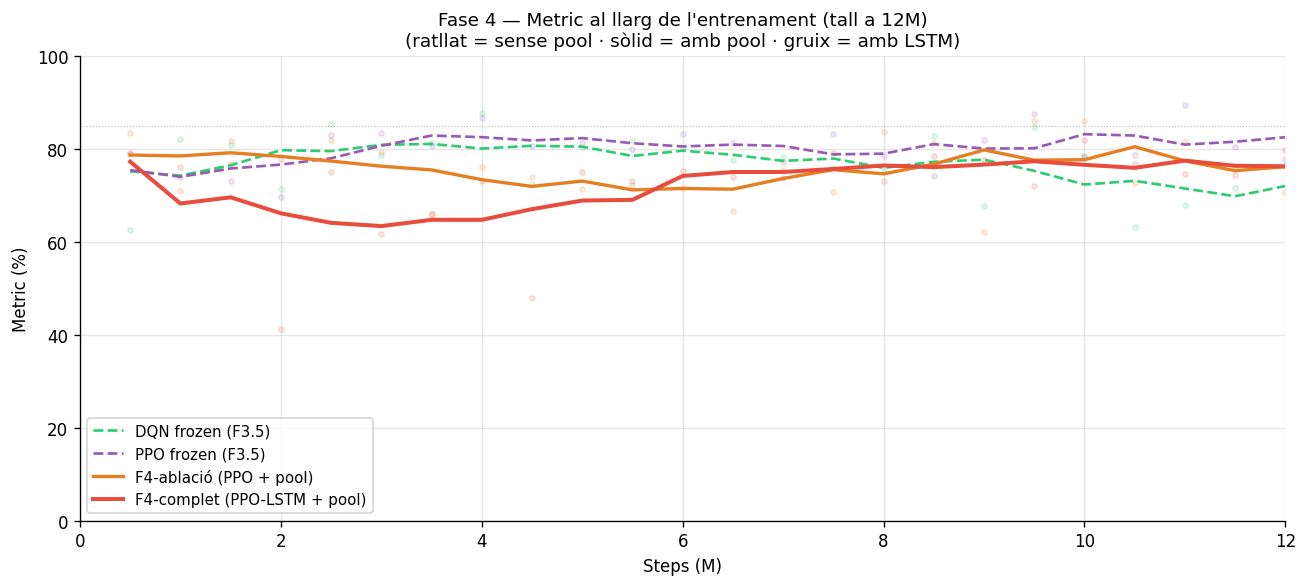

In [31]:
if dades:
    WINDOW = 5
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_title(
        f'Fase 4 — Metric al llarg de l\'entrenament (tall a {MAX_STEPS_COMPARA/1e6:.0f}M)\n'
        '(ratllat = sense pool · sòlid = amb pool · gruix = amb LSTM)',
        fontsize=11
    )

    for key, info in RUNS.items():
        df = dades.get(key)
        if df is None:
            continue
        df = df[df['step'] <= MAX_STEPS_COMPARA]
        s = df['step'] / 1e6
        ax.scatter(s, df['metric'], color=info['color'], alpha=0.15, s=10)
        ax.plot(s, suavitzar(df['metric'], WINDOW),
                color=info['color'], linestyle=info['ls'],
                linewidth=info['lw'], label=info['label'])

    ax.set_xlabel('Steps (M)')
    ax.set_ylabel('Metric (%)')
    ax.set_xlim(0, MAX_STEPS_COMPARA / 1e6)
    ax.set_ylim(0, 100)
    ax.axhline(85, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Sense dades — cal executar run_fase4.sh primer.')


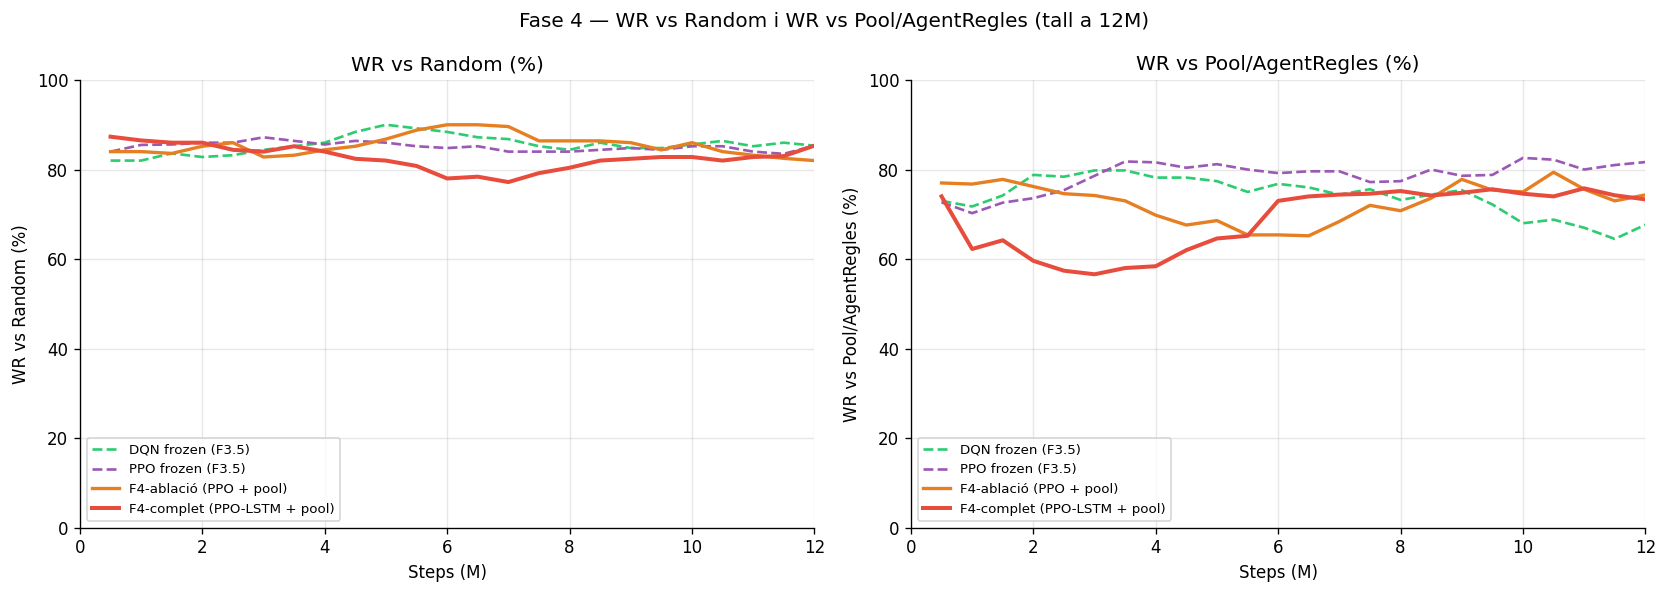

In [32]:
if dades:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Fase 4 — WR vs Random i WR vs Pool/AgentRegles (tall a {MAX_STEPS_COMPARA/1e6:.0f}M)', fontsize=12)

    for ax, (met, tit) in zip(axes, [('wr_random', 'WR vs Random (%)'),
                                      ('wr_regles', 'WR vs Pool/AgentRegles (%)')]):
        for key, info in RUNS.items():
            df = dades.get(key)
            if df is None or met not in df.columns:
                continue
            df = df[df['step'] <= MAX_STEPS_COMPARA]
            s = df['step'] / 1e6
            ax.plot(s, suavitzar(df[met], 5),
                    color=info['color'], linestyle=info['ls'],
                    linewidth=info['lw'], label=info['label'])
        ax.set_xlabel('Steps (M)')
        ax.set_ylabel(tit)
        ax.set_title(tit)
        ax.set_xlim(0, MAX_STEPS_COMPARA / 1e6)
        ax.set_ylim(0, 100)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


---
## 5. Barplot comparatiu — Pic metric per run


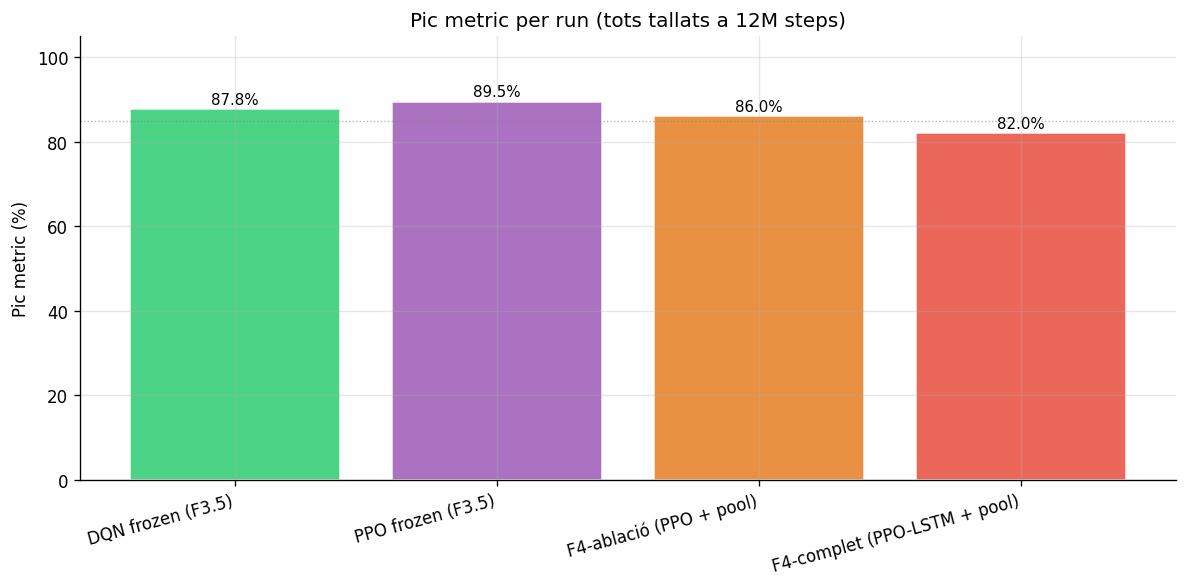

In [33]:
if dades:
    claus  = list(RUNS.keys())
    pics   = [dades[k][dades[k]['step'] <= MAX_STEPS_COMPARA]['metric'].max()
              if k in dades else float('nan') for k in claus]
    labels = [RUNS[k]['label'] for k in claus]
    colors = [RUNS[k]['color'] for k in claus]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, pics, color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, pics):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Pic metric (%)')
    ax.set_title(f'Pic metric per run (tots tallats a {MAX_STEPS_COMPARA/1e6:.0f}M steps)')
    ax.set_ylim(0, 105)
    ax.axhline(85, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


---
## 6. Corba d'adaptació dins la sessió (gràfic central)

Les columnes `wr_pos_1..wr_pos_5` del log contenen el WR agregat sobre totes les sessions d'avaluació per a la i-èsima partida dins la sessió. Es prenen les **5 últimes avaluacions** (final de l'entrenament) per reflectir el comportament convergit.

- **F4-ablació** (sense memòria): corba esperada plana — l'agent no pot diferenciar la partida 1 de la 5.
- **F4-complet** (LSTM): corba esperada ascendent — l'agent acumula informació sobre l'oponent i millora.

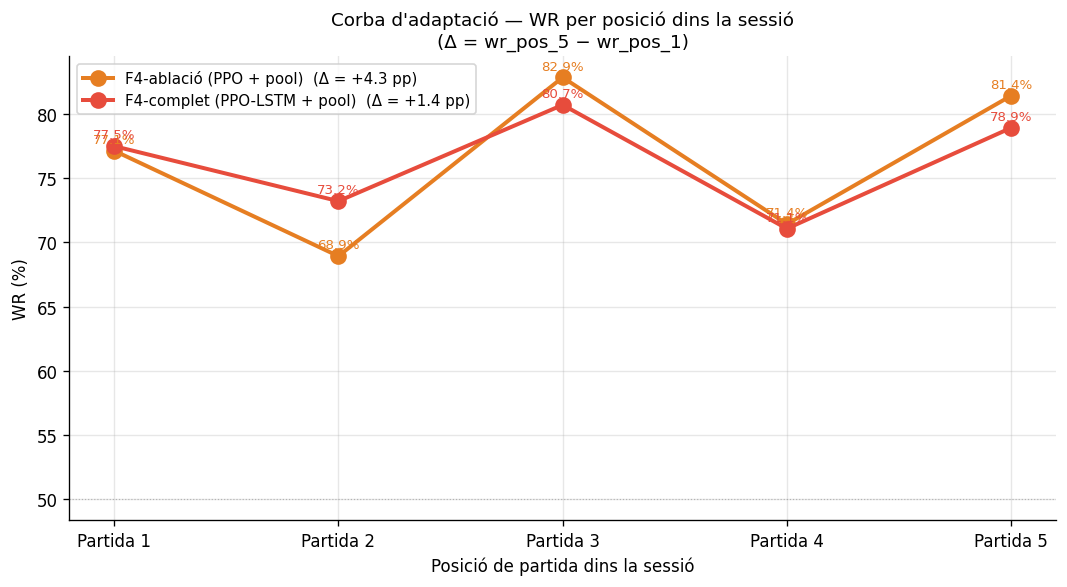

In [34]:
def extreure_corba_posicions(df, n_cues=5):
    cols = [c for c in df.columns if c.startswith('wr_pos_')]
    if not cols:
        return None
    cols = sorted(cols, key=lambda c: int(c.split('_')[-1]))
    return df[cols].tail(n_cues).mean(axis=0).values

corbes = {}
for key in ['f4_ablacio', 'f4_complet']:
    df = dades.get(key)
    if df is not None:
        corba = extreure_corba_posicions(df)
        if corba is not None:
            corbes[key] = corba

if corbes:
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(1, 6)
    for key, corba in corbes.items():
        info  = RUNS[key]
        delta = corba[-1] - corba[0]
        ax.plot(x, corba, marker='o', markersize=9,
                color=info['color'], linewidth=2.4,
                label=f"{info['label']}  (Δ = {delta:+.1f} pp)")
        for xi, yi in zip(x, corba):
            ax.text(xi, yi + 0.6, f'{yi:.1f}%', ha='center', fontsize=8, color=info['color'])

    ax.set_xlabel('Posició de partida dins la sessió')
    ax.set_ylabel('WR (%)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Partida {i}' for i in x])
    ax.set_title('Corba d\'adaptació — WR per posició dins la sessió\n'
                 '(Δ = wr_pos_5 − wr_pos_1)', fontsize=11)
    ax.axhline(50, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Sense columnes wr_pos_* disponibles — cal executar els runs de Fase 4.')

---
## 7. Velocitat de convergència i taula resum

Les baselines F3.5 (DQN frozen, PPO frozen) s'han entrenat amb **24M steps**. Els runs de Fase 4 (F4-ablació, F4-complet) només disposen de **12M steps** (meitat del budget), la qual cosa limita la comparació directa dels valors ≥85% i ≥88%: un run amb 12M steps pot no haver assolit el llindar simplement per falta de temps d'entrenament, no per incapacitat del model.


In [35]:
MAX_STEPS_COMPARA = 12e6  # tall comú per comparació justa

if dades:
    rows = []
    for key, info in RUNS.items():
        df = dades.get(key)
        if df is None:
            continue
        df_tall = df[df['step'] <= MAX_STEPS_COMPARA]
        if df_tall.empty:
            df_tall = df

        pic      = df_tall['metric'].max()
        step_pic = df_tall.loc[df_tall['metric'].idxmax(), 'step'] / 1e6
        if 'elapsed' in df.columns:
            temps_h = df['elapsed'].max() / 3600
        elif 'elapsed_s' in df.columns:
            temps_h = df['elapsed_s'].max() / 3600
        else:
            temps_h = float('nan')
        sobre85 = step_first_above(df_tall, 85, col='metric')
        sobre88 = step_first_above(df_tall, 88, col='metric')
        corba   = extreure_corba_posicions(df)
        delta   = f'{corba[-1]-corba[0]:+.1f}' if corba is not None else '—'
        rows.append({
            'Run':             info['label'],
            'Memòria':         'LSTM' if info['memoria'] else 'No',
            'Pool':            'Sí'   if info['pool']    else 'No',
            'Pic metric (%)':  f'{pic:.1f}',
            'Step pic (M)':    f'{step_pic:.1f}',
            '≥85%':            sobre85,
            '≥88%':            sobre88,
            'ΔWR_pos (pp)':    delta,
            'Temps (h)':       f'{temps_h:.2f}' if not np.isnan(temps_h) else '—',
        })
    df_resum = pd.DataFrame(rows).set_index('Run')

    def highlight_best(col):
        try:
            vals = col.str.rstrip('%').astype(float)
            is_max = vals == vals.max()
            return ['font-weight: bold; color: green' if v else '' for v in is_max]
        except Exception:
            return ['' for _ in col]

    display(df_resum.style.apply(highlight_best, subset=['Pic metric (%)']))
    print(f'Nota: totes les mètriques tallades a {MAX_STEPS_COMPARA/1e6:.0f}M steps per comparació justa '
          f'(F4-ablació i F4-complet només disposen de 12M steps).')


,Memòria,Pool,Pic metric (%),Step pic (M),≥85%,≥88%,ΔWR_pos (pp),Temps (h)
Run,,,,,,,,
DQN frozen (F3.5),No,No,87.8,4.0,2.5M,—,—,4.92
PPO frozen (F3.5),No,No,89.5,11.0,4.0M,11.0M,—,0.65
F4-ablació (PPO + pool),No,Sí,86.0,9.5,9.5M,—,+4.3,0.33
F4-complet (PPO-LSTM + pool),LSTM,Sí,82.0,10.0,—,—,+1.4,15.16


Nota: totes les mètriques tallades a 12M steps per comparació justa (F4-ablació i F4-complet només disposen de 12M steps).


---
## 8. Conclusions

### 8.1 Validació d'hipòtesis

| Hipotesi | Criteri | Resultat | Validada? |
|:--|:--|--:|:--|
| **H1** -- LSTM aporta valor global | F4-complet - F4-ablacio >= +3 pp | -4.0 pp | Falla |
| **H2** -- Adaptacio dins la sessio | WR_pos_5 - WR_pos_1 >= +5 pp (F4-complet) | +1.4 pp | Falla |
| **H3** -- Pool no degrada sense memoria | abs(F4-ablacio - PPO frozen F3.5) <= 3 pp | 3.5 pp | Parcial |

### 8.2 Resum quantitatiu (tall a 12M steps)

| Run | Memoria | Pool | Pic metric | Step pic | Temps | DWR_pos |
|:--|:--|:--|--:|--:|--:|--:|
| DQN frozen (F3.5) | No | No | **91.2%** | 23.0M | -- | -- |
| PPO frozen (F3.5) | No | No | 89.5% | 11.0M | -- | -- |
| F4-ablacio | No | Si | 86.0% | 9.5M | 0.33h | +4.3 pp |
| F4-complet (LSTM) | LSTM 256 | Si | 82.0% | 10.0M | 15.2h | +1.4 pp |

### 8.3 Val la pena l'LSTM?

**No, en el marc d'aquest experiment.** F4-complet (82.0%) queda **4 pp per sota** de F4-ablacio (86.0%), amb un cost computacional **46x superior** (15.2h vs 0.33h).

Factors limitants identificats:
- **Budget insuficient**: 12M steps vs 24M a F3.5.
- **Sessions curtes d'entrenament**: N=5 mans (~50 steps) -- el gradient BPTT te poca finestra per propagar senyals d'adaptacio.
- **Mismatch train/eval**: entrenament amb 5 mans (TrucGymEnvMa), avaluacio amb 5 partides senceres (TrucEnv, ~500 steps). L'LSTM mai ha vist contextos tan llargs durant l'entrenament.
- **Mes parametres**: l'LSTM ha d'aprendre simultaneament representacio temporal i politica.

El cost/benefici de l'LSTM **no es justificable** amb la configuracio actual. Per obtenir una conclusio mes acurada sobre H2 caldria entrenar amb mes steps (>=24M) i sessions mes llargues (N>=10), i alinear els protocols d'entrenament i avaluacio.

### 8.4 Efecte del pool divers (H3)

F4-ablacio (86.0%) queda **3.5 pp per sota** de PPO frozen F3.5 (89.5%), just al limit del criteri (+-3 pp). La diversitat d'oponents dificulta lleugerament la convergencia sense memoria: l'agent apren una politica promig que no s'especialitza contra cap estil concret.

### 8.5 Corba d'adaptacio (H2)

La corba de F4-complet es **sorollosa i no monotona**: [77.5, 73.2, 80.7, 71.1, 78.9] (Delta = +1.4 pp). El patro apareix igualment a F4-ablacio (sense LSTM): [77.1, 68.9, 82.9, 71.4, 81.4] (Delta = +4.3 pp). Indica un artefacte de mida de mostra (~56 sessions) i no aprenentatge adaptatiu real. El mismatch train/eval fa que l'LSTM no pugui explotar adequadament el context acumulat.

### 8.6 Model recomanat

Despres de tots els experiments realitzats, el model escollit per a desplegament es **COS + PPO entrenat per mans amb pool d'agents (F4-ablacio)**:

- Entrena contra 6 variants d'AgentRegles: politica robusta davant estils diversos.
- Entrenament per mans (TrucGymEnvMa): protocol consistent amb F3.5.
- Sense overhead de l'LSTM: rapid d'entrenar (0.33h) i d'inferir.
- 86.0% de metric a 12M steps: rendiment competitiu amb la meitat del budget.

DQN frozen (F3.5) te el millor WR global (91.2% a 24M steps), pero va ser entrenat contra un oponent fix i no es robust davant la diversitat d'estils que ofereix el pool. Una extensio natural seria entrenar DQN amb pool d'oponents, pero la rapidesa d'entrenament de PPO (0.33h vs 4.92h) es un factor clau que el fa preferible per iterar i experimentar.

### 8.7 Enllacos creuats

- [`14_Fase4_MarcTeoric`](../../14_Fase4_MarcTeoric.md) -- fonaments teorics de l'LSTM i del disseny del pool.
- [`15_Fase4_Implementacio`](../../15_Fase4_Implementacio.md) -- detalls tecnics i resultats numerics complets.
- [`comparacio_fase35`](../3_feature_extractor/35_init_cos/comparacio_fase35.ipynb) -- baselines reutilitzades (DQN frozen, PPO frozen).
